In [1]:
import gc
from pathlib import Path

import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, to_tree
from statsmodels.stats.multitest import multipletests

import pandas as pd

from matplotlib import pyplot as plt
from matplotlib.colors import to_rgb, to_hex

from pycirclize import Circos

import seaborn as sns

import anndata as ad
import scanpy as sc

np.random.seed(0)

%matplotlib inline

In [2]:
## Import Scz Adata ##

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

# filter stressed glia and doublets
no_stressed_glia_bool = ~adata.obs['subclass_annotations'].str.contains('Stressed Glia')
singlet_bool = ~adata.obs['pred_dbl']
adata = adata[no_stressed_glia_bool & singlet_bool].copy()

adata.obs['Donor_Sample'] = adata.obs['Donor'].astype('str') + '_' + adata.obs['Sample Name'].astype('str')

In [3]:
# Make PsychAD CellType Equivalents ##

# align psychad celltype column with psychad conventions
adata.obs['PsychAD_CellType'] = adata.obs['CellType'].astype('str')
adata.obs.loc[adata.obs['PsychAD_CellType'].str.contains('Dorsal'), 'PsychAD_CellType'] = 'EN'
adata.obs.loc[adata.obs['PsychAD_CellType'].str.contains('GABAergic'), 'PsychAD_CellType'] = 'IN'
adata.obs.loc[adata.obs['PsychAD_CellType'].str.contains('Astrocyte'), 'PsychAD_CellType'] = 'Astro'
adata.obs.loc[adata.obs['PsychAD_CellType'].str.contains('OPC'), 'PsychAD_CellType'] = 'OPC'
adata.obs.loc[adata.obs['PsychAD_CellType'].str.contains('Oligodendrocyte'), 'PsychAD_CellType'] = 'Oligo'

# make donor sample celltype column 
adata.obs['Donor_Sample_CellType'] = adata.obs['Donor_Sample'].astype('str') + '_' + adata.obs['PsychAD_CellType'].astype('str')

In [4]:
## Read In TPS ##

all_tps = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/psychad_mapping/tps_files/all_tps.csv', index_col=0)

tps_melted = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/psychad_mapping/tps_files/tps_melted.csv', index_col=0)

In [5]:
# Add TPS_SCZ Column To Adata #

# melt SCZ specific TPS dataframe #
all_tps_scz = all_tps[[i for i in all_tps.columns if 'SCZ' in i]]
all_tps_scz.columns = [i.split('_')[0] for i in all_tps_scz.columns]
all_tps_scz['Donor_Sample'] = all_tps_scz.index
all_tps_scz_melted = pd.melt(all_tps_scz, id_vars=['Donor_Sample'], var_name='CellType', value_name='TPS')
donor_sample_celltype_tps_dict  = dict(zip(all_tps_scz_melted['Donor_Sample'] + '_' + all_tps_scz_melted['CellType'],
                                           all_tps_scz_melted['TPS']))


# use dictionary to create TPS SCZ #
adata.obs['TPS_SCZ'] = adata.obs['Donor_Sample_CellType'].map(donor_sample_celltype_tps_dict)

/tmp/ipykernel_1331754/3707960414.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_tps_scz['Donor_Sample'] = all_tps_scz.index


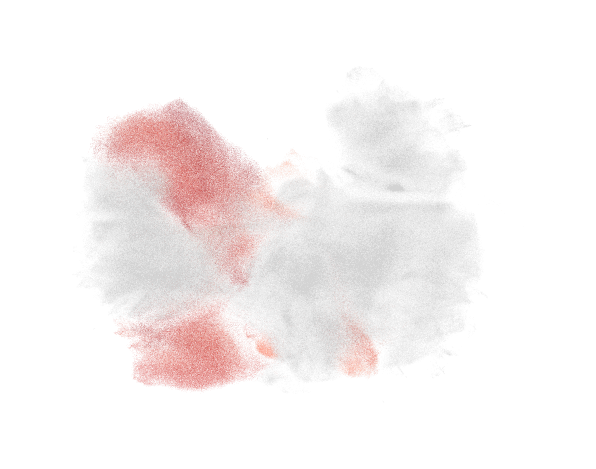

In [81]:
#ax = sc.pl.umap(adata, color='TPS_SCZ', show=False, cmap = sns.diverging_palette(240, 10, s=100, l=30, as_cmap=True))
ax = sc.pl.umap(adata, color='TPS_SCZ', show=False, cmap = 'Reds', colorbar_loc=None)
ax.set_axis_off()
ax.set_title('')

fig = ax.figure  # get the figure from the axes
fig.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_5_umap_tps_scz.png", 
            dpi=500, pad_inches=0, #transparent=True, 
            bbox_inches="tight")

plt.show()
plt.close()

In [7]:
## Make DataFrame For Circos ##

tps_melted = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/psychad_mapping/tps_files/tps_melted.csv', index_col=0)

tps_melted['Broad_Genotype_Celltype'] = tps_melted['Broad_Genotype'] + '_' + tps_melted['CellType'] 

tps_melted.index = tps_melted['Broad_Genotype_Celltype'] 

del tps_melted['Broad_Genotype_Celltype'] 

df_wide = tps_melted.pivot_table(index=["Broad_Genotype", "CellType", "Broad_Genotype_Celltype"], 
                                 columns="Disease",  values="TPS",  aggfunc="mean").reset_index()

df_wide.index = df_wide['Broad_Genotype_Celltype'] 

df_wide_reduced = df_wide[['AD', 'DLBD',	'PD', 'SCZ', 'Tauopathy', 'Vascular', 'Broad_Genotype_Celltype']]

celltypes = ["Astro", "EN", "IN", "OPC", "Oligo"]

In [8]:
# Function to darken colors
def darken_color(color, amount=1):
    """
    amount=0 -> original color
    amount=1 -> black
    """
    r, g, b = to_rgb(color)
    darkened = (
        r * (1 - amount),
        g * (1 - amount),
        b * (1 - amount)
    )
    return to_hex(darkened)

# Original boxplot palette
genotype_palette = {
    'Control': '#a6d854',
    'NRXN1del': '#fc8d62ff',
    '22q11.2del': '#8da0cbff',
    'Idiopathic_Schizophrenia': '#66c2a5ff',
    '3q29del': '#e78ac3',
    '15q13.3del': '#ffd92f'
}

# Automatically generate darker scatter colors
genotype_scatter_palette = {
    k: darken_color(v, amount=0.3)
    for k, v in genotype_palette.items()
}

print(genotype_scatter_palette)

{'Control': '#74973b', 'NRXN1del': '#b06345', '22q11.2del': '#63708e', 'Idiopathic_Schizophrenia': '#478874', '3q29del': '#a26188', '15q13.3del': '#b29821'}


In [63]:
genotype_order = [
    'Control',
    'Idiopathic_Schizophrenia',
    '22q11.2del',
    'NRXN1del',
    '3q29del',
    '15q13.3del'
]

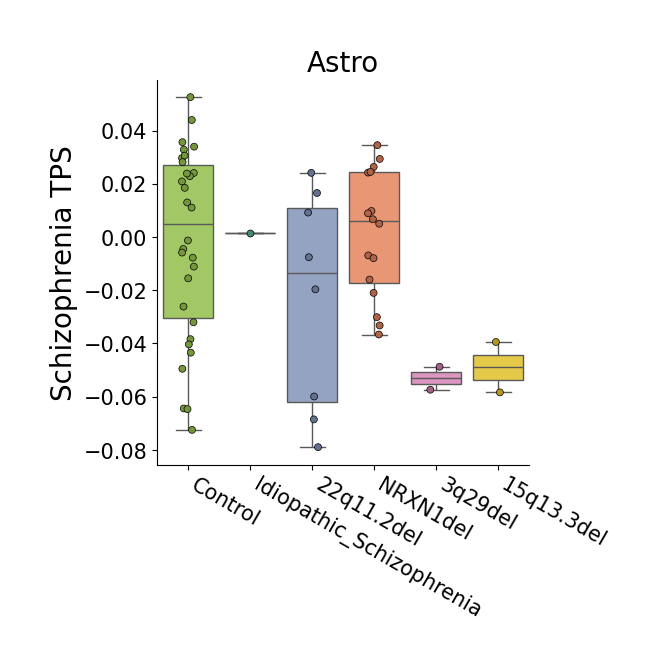

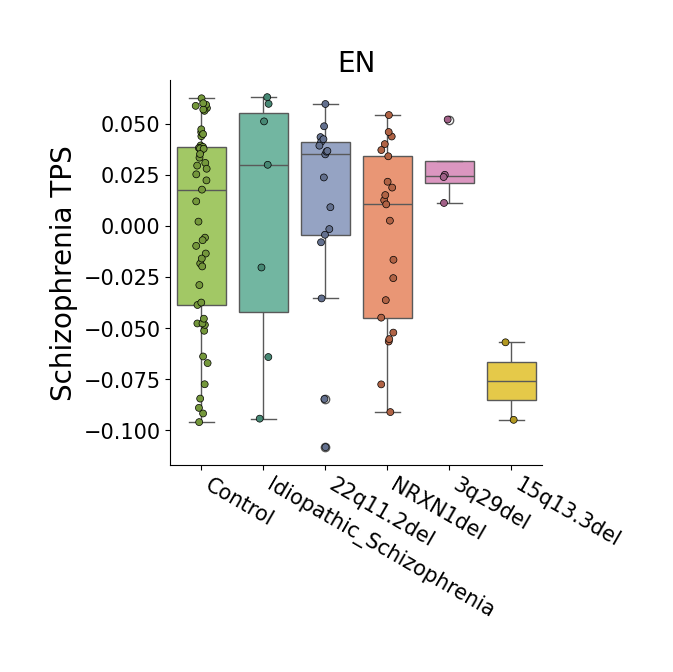

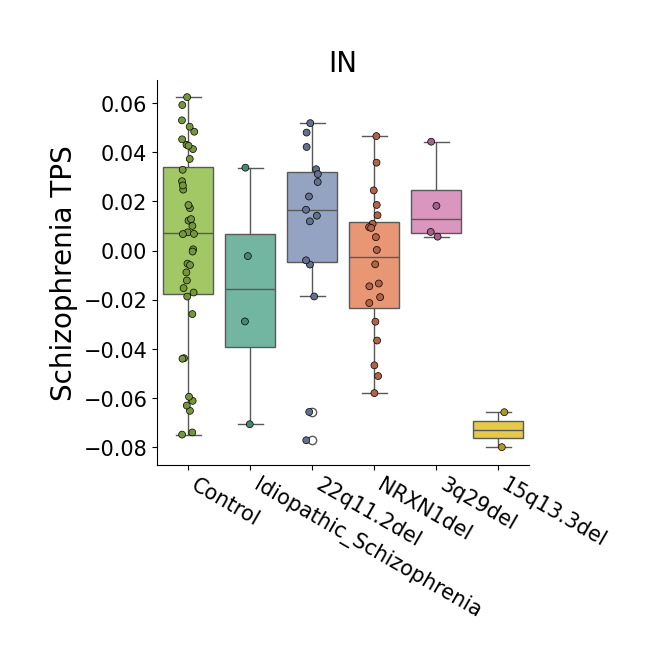

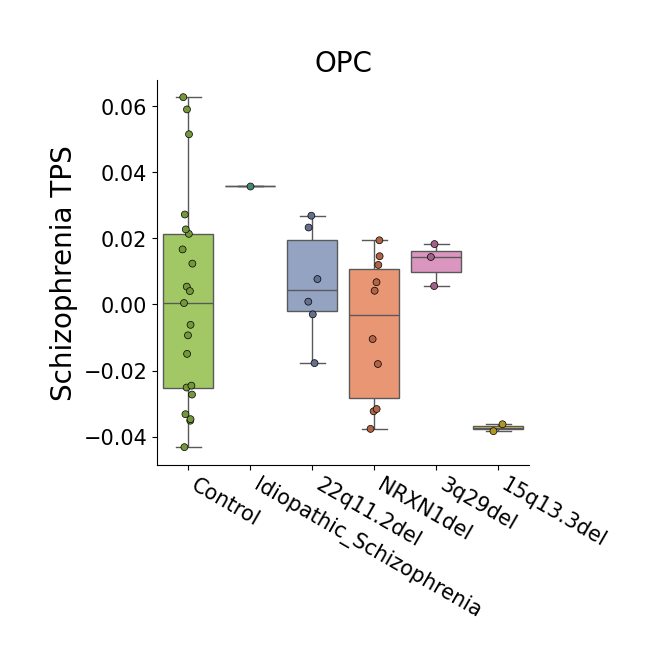

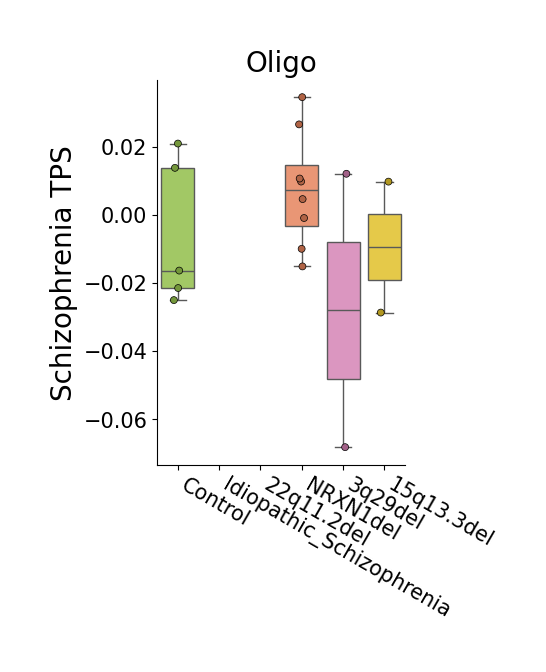

In [72]:
## Make Boxplots with Scatter ##

tps_melted = pd.melt(all_tps, id_vars=['Broad_Genotype'], var_name='CellType_Disease', value_name='TPS')

tps_melted['CellType'] = tps_melted['CellType_Disease'].str.split('_').apply(lambda x: x[0])
tps_melted['Disease'] = tps_melted['CellType_Disease'].str.split('_').apply(lambda x: x[1])

for celltype in tps_melted['CellType'].unique():
    
    temp_tps = tps_melted[
        (tps_melted['CellType'] == celltype) &
        (tps_melted['Disease'] == 'SCZ')
    ]

    # remove NaN
    temp_tps = temp_tps[temp_tps['TPS'].notnull()]

    # make sure empty categories dont show
    temp_tps['Broad_Genotype'] = temp_tps['Broad_Genotype'].astype('str')

    ## plott

    # even out widths
    n_groups = temp_tps['Broad_Genotype'].nunique()
    fig_width = max(4, n_groups * 1.5)
    fig_width = n_groups * 0.8
    
    fig, ax = plt.subplots(figsize=(fig_width, 5))
    
    ax = sns.boxplot(temp_tps, x='Broad_Genotype', y='TPS', hue='Broad_Genotype', palette=genotype_palette, order=genotype_order)
    
    sns.stripplot(data=temp_tps, x='Broad_Genotype', y='TPS', hue='Broad_Genotype', palette=genotype_scatter_palette,
                  order=genotype_order, dodge=False, jitter=True, alpha=1, ax=ax, edgecolor='black', linewidth=0.5,)
    
    #ax.legend(title='Broad_Genotype', bbox_to_anchor=(1.05, 1), loc='upper left')

    ## fontsize controls
    xtick_fontsize = 15
    ytick_fontsize = 15
    ylabel_fontsize = 20
    
    ## rotate xticklabels
    plt.xticks(rotation=-30, ha='left', fontsize=xtick_fontsize)
    
    ## ytick fontsize
    ax.tick_params(axis='y', labelsize=ytick_fontsize)
    
    ## ylabel fontsize
    ax.set_ylabel('Schizophrenia TPS', fontsize=ylabel_fontsize)
    ax.set_xlabel('')
    ax.set_title(f'{celltype}', fontsize=20)    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    fig.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_5_{celltype}_boxplot.svg", dpi=500, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [ ]:
['Control', 'Idiopathic_Schizophrenia', '22q11.2del', 'NRXN1del', '3q29del', '15q13.3del']

In [ ]:
pd.Categorical(temp_tps['Broad_Genotype']

In [62]:
tps_melted['Broad_Genotype'].unique()

array(['NRXN1del', 'Control', '22q11.2del', 'Idiopathic_Schizophrenia',
       '3q29del', '15q13.3del'], dtype=object)

In [77]:
celltype_df_wide_reduced

,AD,DLBD,PD,SCZ,Tauopathy,Vascular
15q13.3de,-0.001562,-0.003640,-0.076648,-0.009545,-0.038745,-0.031433
3q29de,0.008228,0.006762,0.056218,-0.028156,0.029348,0.030726
Contr,0.004165,-0.000889,-0.009514,-0.005704,-0.005254,-0.001083
NRXN1de,-0.003183,-0.000983,0.006258,0.007448,0.004125,0.000224


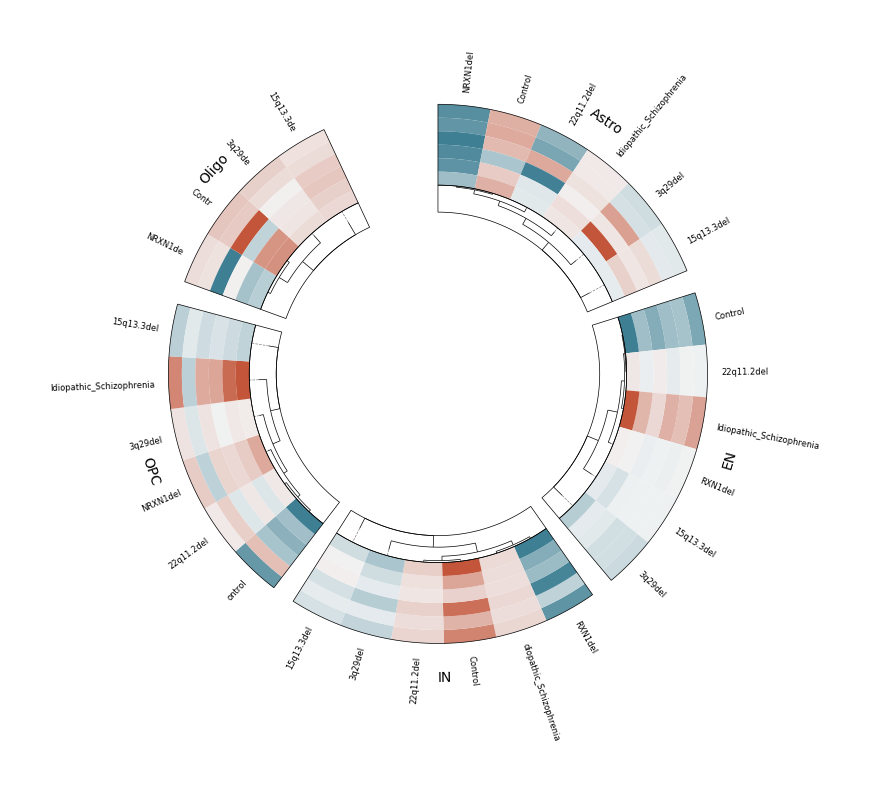

In [75]:
## Plot Circos ##


# 1 - Build Circos Matrices
celltypes = ["Astro", "EN", "IN", "OPC", "Oligo"]

trees = {}
matrices = {}
sizes = {}
label_orders = {}
matrices = {}

for ct in celltypes:
    
    celltype_df_wide_reduced = df_wide_reduced[df_wide_reduced['Broad_Genotype_Celltype'].str.contains(ct)]
    celltype_df_wide_reduced.index.name = None
    celltype_df_wide_reduced.columns.name = None
    del celltype_df_wide_reduced['Broad_Genotype_Celltype']
    celltype_df_wide_reduced.index = [i.strip(f'_{ct}') for i in celltype_df_wide_reduced.index.tolist()]

    matrices[ct] = celltype_df_wide_reduced

    labels = [i.strip(f'_{ct}') for i in celltype_df_wide_reduced.index.tolist()]
    label_orders[ct] = celltype_df_wide_reduced.index

    mat = celltype_df_wide_reduced

    # Scipy Cluster
    dist = pdist(mat.values, metric="euclidean")
    link = linkage(dist, method="average")

    def build_newick(node, labels):
        if node.is_leaf():
            return labels[node.id]
        left = build_newick(node.left, labels)
        right = build_newick(node.right, labels)
        return f"({left}:{node.dist:.4f},{right}:{node.dist:.4f})"

    root = to_tree(link)
    newick = build_newick(root, labels) + ";"

    trees[ct] = newick
    sizes[ct] = len(labels)

# 2 - Initialize Circos 
spaces = [5, 5, 5, 5, 25]

circos = Circos(sizes, space=spaces)

# 3 - Plot 
for sector in circos.sectors:

    ct = sector.name

    mat = matrices[ct].copy()
    newick = trees[ct]
    labels = label_orders[ct]

    # -------------------------
    # TREE
    # -------------------------
    tree_track = sector.add_track((60, 70))
    tree_track.axis()
    tree_track.tree(newick, leaf_label_size=6, leaf_label_rmargin=35, align_leaf_label=True, reverse=True, ladderize=True)

    # -------------------------
    # HEATMAP (NO INTERNAL TREE ACCESS)
    # -------------------------
    heatmap_track = sector.add_track((70, 100))
    heatmap_track.axis()

    # IMPORTANT: enforce same order as original labels
    mat = mat.loc[labels]

    #cmap = sns.color_palette("mako", as_cmap=True)
    cmap = sns.diverging_palette(220, 20, as_cmap=True)
    #cmap = sns.cubehelix_palette(start=0.5, rot=-0.75, as_cmap=True)

    # from matplotlib.colors import LinearSegmentedColormap

    # cmap = LinearSegmentedColormap.from_list(
    #     "custom",
    #     [
    #         "#f7f7f7",   # light neutral
    #         "#8da0cb",   # your blue
    #         "#66c2a5",   # your teal
    #         "#5e4fa2"    # deeper purple anchor
    #     ]
    # )
    
    heatmap_track.heatmap(mat.values.T, cmap=cmap, show_value=False)

    sector.text(ct, r=110, size=10)

# -------------------------
# 4. RENDER
# -------------------------
fig = circos.plotfig()

fig.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_5_dendrogram_circos_tps_labels.svg", dpi=300, bbox_inches="tight")

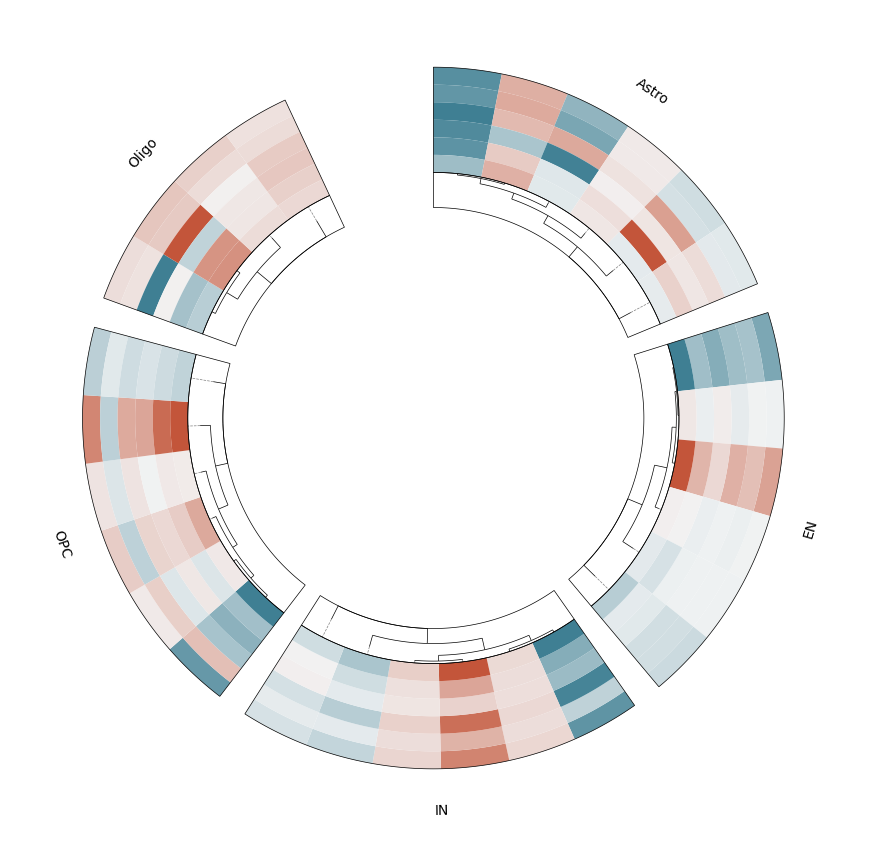

In [76]:
# 2 - Initialize Circos 
# 2 - Initialize Circos 
spaces = [5, 5, 5, 5, 25]

circos = Circos(sizes, space=spaces)

# 3 - Plot 
for sector in circos.sectors:

    ct = sector.name

    mat = matrices[ct].copy()
    newick = trees[ct]
    labels = label_orders[ct]

    # -------------------------
    # TREE
    # -------------------------
    tree_track = sector.add_track((60, 70))
    tree_track.axis()
    tree_track.tree(newick, leaf_label_size=0, leaf_label_rmargin=35, align_leaf_label=True, reverse=True, ladderize=True)

    # -------------------------
    # HEATMAP (NO INTERNAL TREE ACCESS)
    # -------------------------
    heatmap_track = sector.add_track((70, 100))
    heatmap_track.axis()

    # IMPORTANT: enforce same order as original labels
    mat = mat.loc[labels]

    heatmap_track.heatmap(mat.values.T, cmap=sns.diverging_palette(220, 20, as_cmap=True), show_value=False)

    sector.text(ct, r=110, size=10)

# -------------------------
# 4. RENDER
# -------------------------
fig = circos.plotfig()

fig.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_5_dendrogram_circos_tps_labels_no_labels.svg", dpi=300, bbox_inches="tight")

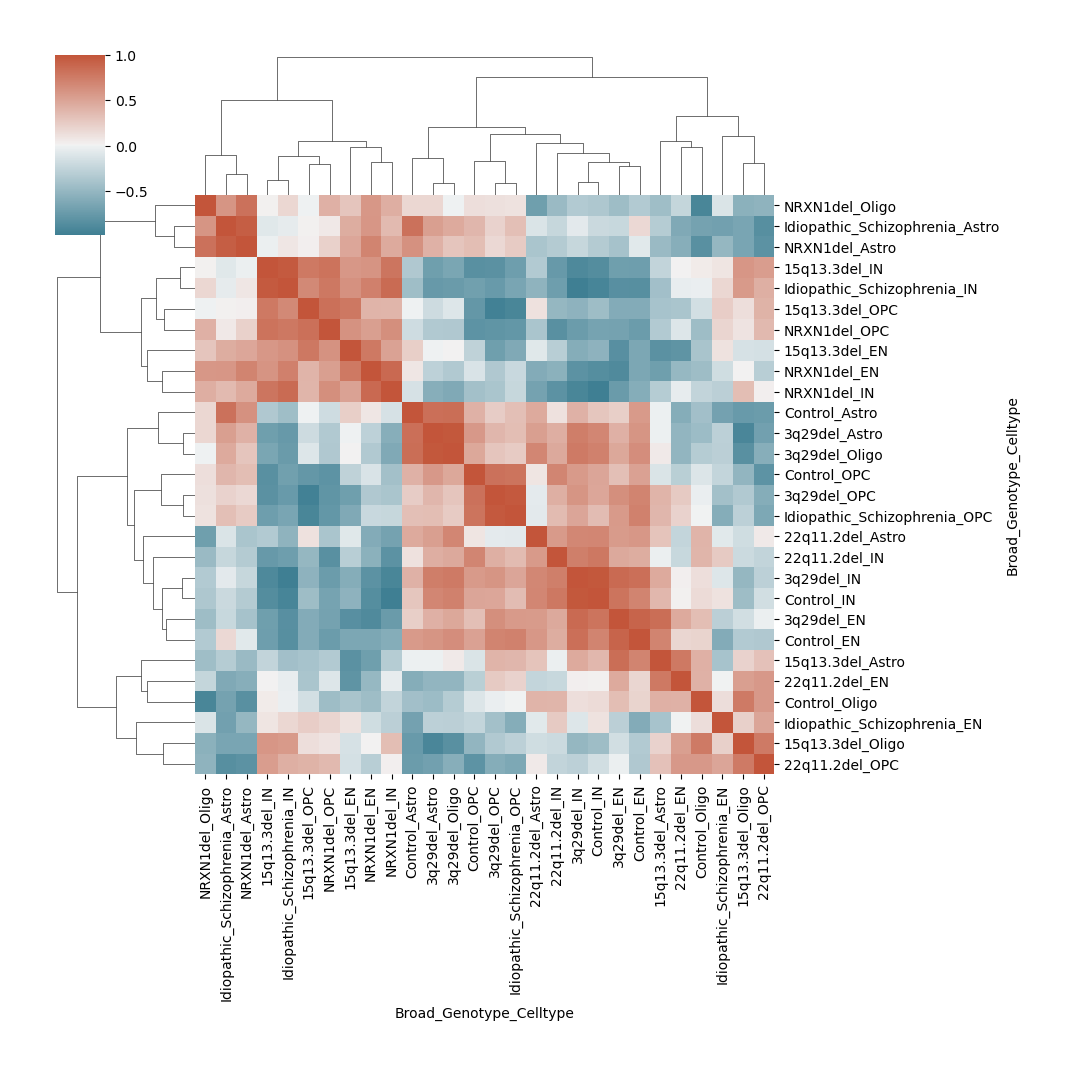

In [55]:
g = sns.clustermap(df_wide_reduced[df_wide_reduced.columns[0:-1]].T.corr(), cmap=sns.diverging_palette(220, 20, as_cmap=True))

g.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_5_trajectory_clustermap.svg",
            dpi=500, bbox_inches="tight")

In [13]:
dreamlet_dge = pd.read_parquet('/mnt/sdb/scz_meta_analysis_processed/psychad_mapping/res_meta.parquet')

scz_dreamlet_dge =  dreamlet_dge[(dreamlet_dge['method'] == 'FE') & 
                                 (dreamlet_dge['AnnoLevel'] == 'class') & 
                                 (dreamlet_dge['coef'] == 'm11x')]

## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

scz_dreamlet_dge_adj = fdr_per_celltype(scz_dreamlet_dge)

/tmp/ipykernel_1331754/919971837.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dge_df['p.adjusted'] = None
/tmp/ipykernel_1331754/919971837.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dge_df['significant_fdr'] = False


In [14]:
## Read in DEG Lists ##

CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

# by manuscript #
dge_fernando = pd.read_csv(Path(CSV_PATH) / 'dreamlet_fernando_dge_scz_results.csv')
dge_shin = pd.read_csv(Path(CSV_PATH) / 'dreamlet_shin_dge_scz_results.csv')
dge_purcell = pd.read_csv(Path(CSV_PATH) / 'dreamlet_purcell_dge_scz_results.csv')
dge_sebastian = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sebastian_dge_scz_results.csv')
dge_sawada = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sawada_dge_scz_results.csv')
dge_notaras = pd.read_csv(Path(CSV_PATH) / 'dreamlet_notaras_dge_scz_results.csv')
dge_rao = pd.read_csv(Path(CSV_PATH) / 'dreamlet_rao_dge_scz_results.csv')
dge_walsh_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_22q11_dge_scz_results.csv')
dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')

# by disease #
dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')
dge_15q13 = dge_walsh_15q13
dge_15q13['p.adjusted'] = dge_15q13['adj.P.Val'] 
dge_3q29 = dge_purcell
dge_3q29['p.adjusted'] = dge_3q29['adj.P.Val'] 

## Calculate FDR ##

dge_nrxn1 = fdr_per_celltype(dge_nrxn1)
dge_22q11 = fdr_per_celltype(dge_22q11)
dge_idiopathic = fdr_per_celltype(dge_idiopathic)

In [15]:
# ################

# ## TOY EXAMPLE ##

# ################

# np.random.seed(0)

# # -------------------------
# # 1. TOY DATA
# # -------------------------
# celltypes = ["Astro", "EN", "IN", "OPC", "Oligo"]

# trees = {}
# matrices = {}
# sizes = {}
# label_orders = {}
# matrices = {}

# for ct in celltypes:

#     labels = [f"{ct}_D{i}" for i in range(len(celltypes))]
#     label_orders[ct] = labels

#     mat = pd.DataFrame(
#         np.random.randn(5, 6),
#         index=labels,
#         columns=["SCZ", "AD", "PD", "Tau", "Vascular", "DLBD"]
#     )

#     matrices[ct] = mat

#     # -------------------------
#     # CLUSTERING
#     # -------------------------
#     dist = pdist(mat.values, metric="euclidean")
#     link = linkage(dist, method="average")

#     def build_newick(node, labels):
#         if node.is_leaf():
#             return labels[node.id]
#         left = build_newick(node.left, labels)
#         right = build_newick(node.right, labels)
#         return f"({left}:{node.dist:.4f},{right}:{node.dist:.4f})"

#     root = to_tree(link)
#     newick = build_newick(root, labels) + ";"

#     trees[ct] = newick
#     sizes[ct] = len(labels)

# # -------------------------
# # 2. CIRCOS INIT
# # -------------------------
# circos = Circos(sizes, space=5)

# # -------------------------
# # 3. PLOT
# # -------------------------
# for sector in circos.sectors:

#     ct = sector.name

#     mat = matrices[ct].copy()
#     newick = trees[ct]
#     labels = label_orders[ct]

#     # -------------------------
#     # TREE
#     # -------------------------
#     tree_track = sector.add_track((60, 70))
#     tree_track.axis()
#     tree_track.tree(newick, leaf_label_size=6, leaf_label_rmargin=35, align_leaf_label=True, reverse=True, ladderize=True)

#     # -------------------------
#     # HEATMAP (NO INTERNAL TREE ACCESS)
#     # -------------------------
#     heatmap_track = sector.add_track((70, 100))
#     heatmap_track.axis()

#     # IMPORTANT: enforce same order as original labels
#     mat = mat.loc[labels]

#     heatmap_track.heatmap(
#         mat.values.T,
#         cmap="viridis",
#         show_value=False)

#     sector.text(ct, r=110, size=10)

# # -------------------------
# # 4. RENDER
# # -------------------------
# fig = circos.plotfig()